##Testeos Santiago


In [ ]:
from collections import deque
#import headpq, itertools

DIRS = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}

#Clase del player/box actual:
class SokobanState:
    __slots__ = ('player', 'box') #Ejemplo: player, box = (1,1) , (-1,1)
    def __init__(self, player, box):
        self.player = player
        self.box = box
    def __eq__(self, other):
        return self.player == other.player and self.box == other.box #Compara igualdad entre box y player
    def __hash__(self):
        return hash((self.player, self.box))

class SokobanProblem:
    def __init__(self, grid, player0, box0, target):
        self.grid = grid
        self.rows, self.cols = len(grid), len(grid[0])
        self.initial = SokobanState(player0, box0)
        self.target = target

    def is_wall(self, pos):
        r, c = pos
        if not (0 <= r < self.rows and 0 <= c < self.cols):
          # Dada una posicion (r, c), corrobora si se encuentra una pared o un limite de mapa (considerado tambien pared)
            return True
        return self.grid[r][c] == '#'

    def is_goal(self, state):
        return state.box == self.target

    def result(self, state, action):
        dr, dc = DIRS[action]
        new_player = (state.player[0] + dr, state.player[1] + dc)
        if self.is_wall(new_player): #Bloquea movimientos a paredes
            return None
        if new_player == state.box: #Mueve la caja cuando player = box
            new_box = (state.box[0] + dr, state.box[1] + dc) #Mueve la caja en DIRS action
            if self.is_wall(new_box):
                return None
            return SokobanState(new_player, new_box)
        return SokobanState(new_player, state.box) #Si no hay caja, simplemente actualiza la posicion del player

class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost

    def path(self):
        node, actions = self, []
        while node.parent:
            actions.append(node.action)
            node = node.parent
        return list(reversed(actions))

def expand(problem, node):
    for action in DIRS:
        next_state = problem.result(node.state, action)
        if next_state is not None: #Filtro de acciones no validas
            yield Node(next_state, node, action, node.path_cost + 1)

In [ ]:
import time

class SearchResult:
    def __init__(self, success, node, expanded_count, frontier_size, elapsed_time):
        self.success = success
        self.node = node
        self.expanded_count = expanded_count #Cuantas veces se aplico 'expand'
        self.frontier_size = frontier_size
        self.elapsed_time = elapsed_time
        self.cost = node.path_cost if node else None
        self.solution = node.path() if node else None

    def report(self):
        print(f"Resultado: {'éxito' if self.success else 'fracaso'}")
        print(f"Costo de la solución: {self.cost}")
        print(f"Nodos expandidos: {self.expanded_count}")
        print(f"Nodos en frontera (al finalizar): {self.frontier_size}")
        print(f"Solución: {self.solution}")
        print(f"Tiempo de procesamiento: {self.elapsed_time:.6f} s")

## Condiciones Iniciales

In [ ]:
grid = [
    "#######",
    "#.....#",
    "#.....#",
    "#.....#",
    "#######",
]
player0 = (1, 1)   # (fila, columna) inicial del jugador
box0 = (2, 2)      # (fila, columna) inicial de la caja
target = (3, 4)    # (fila, columna) del destino

problem = SokobanProblem(grid, player0, box0, target)

### Métodos de Búsqueda Desinformados:

In [ ]:
#BFS: Breadth First Search

def bfs(problem):
    t0 = time.perf_counter()
    start = Node(problem.initial)
    frontier = deque([start])
    explored = {start.state}
    expanded_count = 0

    while frontier:
        node = frontier.popleft()               # Sale el mas antiguo (menos profundo)
        if problem.is_goal(node.state):
            elapsed = time.perf_counter() - t0
            return SearchResult(True, node, expanded_count, len(frontier), elapsed)

        expanded_count += 1
        for child in expand(problem, node):
            if child.state not in explored:
                explored.add(child.state)
                frontier.append(child)

    elapsed = time.perf_counter() - t0
    return SearchResult(False, None, expanded_count, len(frontier), elapsed)


#DFS: Depth First Search
def dfs(problem):
    t0 = time.perf_counter()
    start = Node(problem.initial)
    frontier = [start]
    explored = {start.state}
    expanded_count = 0

    while frontier:
        node = frontier.pop()                    # Sale el ultimo agregado (mas profundo)
        if problem.is_goal(node.state):
            elapsed = time.perf_counter() - t0
            return SearchResult(True, node, expanded_count, len(frontier), elapsed)

        expanded_count += 1
        for child in expand(problem, node):
            if child.state not in explored:
                explored.add(child.state)
                frontier.append(child)

    elapsed = time.perf_counter() - t0
    return SearchResult(False, None, expanded_count, len(frontier), elapsed)


print("\n Resultado para BFS (Breadth First Search)")
result = bfs(problem)
result.report()
print("\n Resultado para DFS (Depth First Search)")
result2 = dfs(problem)
result2.report()


 Resultado para BFS (Breadth First Search)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 76
Nodos en frontera (al finalizar): 36
Solución: ['D', 'R', 'R', 'U', 'R', 'D']
Tiempo de procesamiento: 0.000522 s

 Resultado para DFS (Depth First Search)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 124
Nodos en frontera (al finalizar): 5
Solución: ['R', 'D', 'L', 'D', 'R', 'R']
Tiempo de procesamiento: 0.000551 s


Métodos de Búsqueda Informados
Heurísticos.

In [ ]:
class Heuristic:
    def __call__(self, state, problem):
        raise NotImplementedError("Cada heurística concreta debe implementar __call__")

class ManhattanBoxToTarget(Heuristic):
    def __call__(self, state, problem):
        return abs(state.box[0] - problem.target[0]) + abs(state.box[1] - problem.target[1])

class PlayerBehindBox(Heuristic):
    def __call__(self, state, problem):
        if state.box == problem.target:
            return 0  # estado solucion
        d = abs(state.player[0] - state.box[0]) + abs(state.player[1] - state.box[1])
        return max(d - 1, 0)

class CombinedHeuristic(Heuristic):
    def __init__(self, heuristics):
        self.heuristics = heuristics  # lista de instancias de Heuristic

    def __call__(self, state, problem):
        return max(h(state, problem) for h in self.heuristics)

class Corner(Heuristic):
    def __call__(self, state, problem):
        '''Caso extra para evitar que la caja se quede encerrada en una posicion
        invalida, a excepcion que sea el caso solucion'''
        if state.box == problem.target:
            return 0  # estado solucion
        r, c = state.box
        up = problem.is_wall((r - 1, c))
        down = problem.is_wall((r + 1, c))
        left = problem.is_wall((r, c - 1))
        right = problem.is_wall((r, c + 1))
        if (up and left) or (up and right) or (down and left) or (down and right):
            return float('inf') #En posicion invalida resulta en h = infinito positivo
        return 0


h1 = ManhattanBoxToTarget()
h2 = PlayerBehindBox()
h_safe = CombinedHeuristic([h1, Corner()])

In [ ]:
import heapq, itertools

def greedy(problem, heuristic):
    t0 = time.perf_counter()
    counter = itertools.count()
    start = Node(problem.initial)
    frontier = [(heuristic(start.state, problem), next(counter), start)]
    explored = {start.state}
    expanded_count = 0

    while frontier:
      h_value, counter_value, node = heapq.heappop(frontier) #Se elimina el de menor h(n)
      if problem.is_goal(node.state):
            elapsed = time.perf_counter() - t0
            return SearchResult(True, node, expanded_count, len(frontier), elapsed)

      expanded_count += 1
      for child in expand(problem, node):
            if child.state not in explored: #Evita repetir nodos explorados, es un set()
                explored.add(child.state)
                heapq.heappush(frontier, (heuristic(child.state, problem), next(counter), child))

    elapsed = time.perf_counter() - t0
    return SearchResult(False, None, expanded_count, len(frontier), elapsed)

print("\n Resultado para Greedy (Manhattan)")
result_greedy_h1 = greedy(problem, h1)
result_greedy_h1.report()

print("\n Resultado para Greedy (Player behind box)")
result_greedy_h2 = greedy(problem, h2)
result_greedy_h2.report()

print("\n Resultado para Greedy (Manhattan + Corner deadlock)")
result_greedy_safe = greedy(problem, h_safe)
result_greedy_safe.report()


 Resultado para Greedy (Manhattan)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 9
Nodos en frontera (al finalizar): 11
Solución: ['D', 'R', 'R', 'U', 'R', 'D']
Tiempo de procesamiento: 0.000101 s

 Resultado para Greedy (Player behind box)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 24
Nodos en frontera (al finalizar): 29
Solución: ['R', 'D', 'L', 'D', 'R', 'R']
Tiempo de procesamiento: 0.000169 s

 Resultado para Greedy (Manhattan + Corner deadlock)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 9
Nodos en frontera (al finalizar): 11
Solución: ['D', 'R', 'R', 'U', 'R', 'D']
Tiempo de procesamiento: 0.000112 s


###Método A*
f(n) = g(n) + h(n)

In [ ]:
def astar(problem, heuristic):
    t0 = time.perf_counter()
    counter = itertools.count()
    start = Node(problem.initial)
    frontier = [(heuristic(start.state, problem), next(counter), start)]
    best_cost = {start.state: 0}          # dict, no set: guarda el mejor g(n) conocido [README]
    expanded_count = 0

    while frontier:
        f_value, counter_value, node = heapq.heappop(frontier)
        if problem.is_goal(node.state):
            elapsed = time.perf_counter() - t0
            return SearchResult(True, node, expanded_count, len(frontier), elapsed)

        expanded_count += 1
        for child in expand(problem, node):
            if child.state not in best_cost or child.path_cost < best_cost[child.state]:
              #Se recorre si nunca se observo o si posee un costo menor a su anterior iteracion (nodo).
                best_cost[child.state] = child.path_cost
                f = child.path_cost + heuristic(child.state, problem)
                heapq.heappush(frontier, (f, next(counter), child))

    elapsed = time.perf_counter() - t0
    return SearchResult(False, None, expanded_count, len(frontier), elapsed)

print("\n Resultado para A* (Manhattan)")
result_astar_h1 = astar(problem, h1)
result_astar_h1.report()

print("\n Resultado para A* (Manhattan + Corner deadlock)")
result_astar_safe = astar(problem, h_safe)
result_astar_safe.report()


 Resultado para A* (Manhattan)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 37
Nodos en frontera (al finalizar): 25
Solución: ['D', 'R', 'R', 'U', 'R', 'D']
Tiempo de procesamiento: 0.000700 s

 Resultado para A* (Manhattan + Corner deadlock)
Resultado: éxito
Costo de la solución: 6
Nodos expandidos: 37
Nodos en frontera (al finalizar): 25
Solución: ['D', 'R', 'R', 'U', 'R', 'D']
Tiempo de procesamiento: 0.002372 s



Generando GIF de la solucion con A* + h2...
Solucion encontrada con costo 6 movimientos.


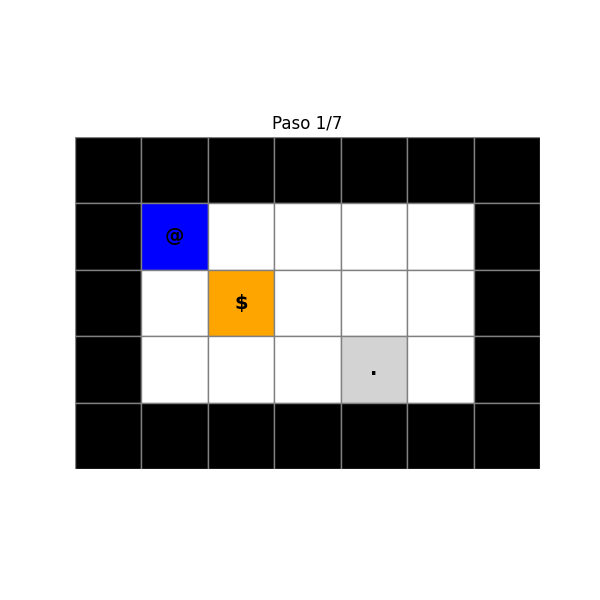

In [ ]:
'''Gif Astar (claude)'''

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image

def save_solution_gif(problem, path, filename='solucion.gif'):
    """
    problem: instancia de SokobanProblem (para leer walls/target/dims, que NO cambian por estado)
    path: lista de acciones, tal como la devuelve Node.path() / result.solution
    """
    if not path:
        print("No hay camino para generar GIF.")
        return

    # !!! Reconstruye la secuencia de estados aplicando problem.result(),
    # en vez de buscar la acción entre get_successors() como en tu original.
    states = [problem.initial]
    current = problem.initial
    for action in path:
        current = problem.result(current, action)
        states.append(current)

    fig, ax = plt.subplots(figsize=(6, 6))

    def render_state(state, ax):
        ax.clear()
        # !!! rows/cols/walls salen de 'problem', no del estado (el estado no los tiene)
        grid = [[' ' for _ in range(problem.cols)] for _ in range(problem.rows)]
        for r in range(problem.rows):
            for c in range(problem.cols):
                if problem.grid[r][c] == '#':
                    grid[r][c] = '#'

        # !!! target(s): soporta tanto una sola caja (problem.target) como
        # multi-caja (problem.targets), sin romper si solo tenés una versión
        targets = list(problem.targets) if hasattr(problem, 'targets') else [problem.target]
        for (r, c) in targets:
            if grid[r][c] == ' ':
                grid[r][c] = '.'

        # !!! caja(s): soporta state.box como tupla única o frozenset (multi-caja)
        boxes = list(state.box) if isinstance(state.box, frozenset) else [state.box]
        for (r, c) in boxes:
            grid[r][c] = '*' if (r, c) in targets else '$'

        pr, pc = state.player
        grid[pr][pc] = '+' if (pr, pc) in targets else '@'

        colors = {
            ' ': 'white', '#': 'black', '.': 'lightgray',
            '$': 'orange', '*': 'gold', '@': 'blue', '+': 'cyan'
        }
        for r in range(problem.rows):
            for c in range(problem.cols):
                ch = grid[r][c]
                color = colors.get(ch, 'white')
                ax.add_patch(plt.Rectangle((c, -r-1), 1, 1, color=color, ec='gray'))
                ax.text(c+0.5, -r-0.5, ch, ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_xlim(0, problem.cols)
        ax.set_ylim(-problem.rows, 0)
        ax.set_aspect('equal')
        ax.axis('off')

    def update(frame):
        render_state(states[frame], ax)
        ax.set_title(f'Paso {frame+1}/{len(states)}')

    ani = animation.FuncAnimation(fig, update, frames=len(states), repeat=False)
    ani.save(filename, writer='pillow', fps=2)
    plt.close()



h2 = PlayerBehindBox()

print("\nGenerando GIF de la solucion con A* + h2...")
result = astar(problem, h2)

if result.success:
    print(f"Solucion encontrada con costo {result.cost} movimientos.")
    save_solution_gif(problem, result.solution, 'solucion_A_estrella.gif')
    display(Image('solucion_A_estrella.gif'))
else:
    print("No se encontro solucion para generar el GIF.")

\#Implementacion con 1 < cajas (No se hizo al final, por tiempo)


In [ ]:
class SokobanState:
    __slots__ = ('player', 'box')
    def __init__(self, player, box):
        self.player = player
        self.box = box  # frozenset de tuplas (r, c), no importa el orden
    def __eq__(self, other):
        return self.player == other.player and self.boxes == other.boxes
    def __hash__(self):
        return hash((self.player, self.box))